In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import multiprocess as mp
import numpy as np
import pandas as pd
import pybedtools
import h5py
import pickle
import scipy
from scipy import stats
import cooler
import cooltools
import bioframe
from cooltools import insulation
from fitter import Fitter
from scipy import stats as st
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from sys import getsizeof
import contact_hunter
import os
import gc

/home/anna/anaconda3/lib/python3.9/site-packages/cooltools/lib/numutils.py:652: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def iterative_correction_symmetric(
/home/anna/anaconda3/lib/python3.9/site-packages/cooltools/lib/numutils.py:727: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def iterative_correction_asymmetric(x, max_iter=1000, tol=1e-5, verbose=Fals

In [2]:
def norm(ff,ch):
    s=ff.matrix(balance=True).fetch(ch)
    D=np.zeros(len(s))
    for i in range (len(s)):
        D[i]=np.nanmean(s.diagonal(i))
     
    A=np.zeros((len(s),len(s)))
    n=len(s)
    for i in range (len(s)):
        row_id=np.arange(0,(n-i))
        col_id=np.arange(i,n)

        if D[i]!=0:
            A[row_id,col_id]=s[row_id,col_id]/D[i]
            A[col_id,row_id]=s[col_id,row_id]/D[i]

    return(A)


In [3]:
# Matplotlib settings

plt.rc('font', family='Helvetica')
#mpl.rcParams['font.family']='Helvetica'

mpl.rc('lines', linewidth=1.2)

mpl.rc('font', family='Helvetica', size=8)

mpl.rc('axes', labelsize=8, titlesize=8, linewidth=0.4)

mpl.rc('legend', fontsize=8)

mpl.rc('xtick', labelsize=6)

mpl.rc('xtick.major', width=0.4, size=2)

mpl.rc('xtick.minor', width=0.4, size=1)

mpl.rc('ytick', labelsize=6)

mpl.rc('ytick.major', width=0.4, size=2)

mpl.rc('ytick.minor', width=0.4, size=1)

mpl.rcParams['font.family'] = 'Helvetica'

mpl.rc('lines', linewidth=1.2)


In [ ]:
tmp=pd.DataFrame({'chrom':['chr20'],'gene_bin':[22580000],'rs_pos':[20840000]})#FOXA2

In [ ]:
tmp=pd.DataFrame({'chrom':['chr1'],'gene_bin':[99680000],'rs_pos':[98060000]})#FRRS1

In [ ]:
tmp=pd.DataFrame({'chrom':['chr3'],'gene_bin':[181711924],'rs_pos':[181210678]})#SOX2

In [ ]:

files=[    'Eres_iPSC_5kb.sampled_exact.mcool',
       'Artrial_D0_iPSC_5K.mcool',
       'Lu2020_iPSC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
    'Ballerino2022_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Rajarajan_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Zaghi2023_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Ballerino2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Li2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Rahman2023_iPSC_NeuNplus_CRISPRi_Scrambled_A_DpnII-HinfI.sampled_exact.mcool',
 'Wu2021_iPSC_NeuNplus.sampled_exact.mcool',
 'Zaghi2023_iPSC_NeuNplus.sampled_exact.mcool',
 'PsychENCODE_iPSC_NeuNplus.sampled_exact.mcool',
 'Lagarkova_culture_iPSC_NeuNplus.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Heffel_2T.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Heffel_3T.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Rahman2023_FetalBrain.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Heffel_infant.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',       
 'Heffel_adult.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Hu2021_NeuNplus.sampled_exact.mcool',
 'Pletenev2024_NeuNplus.sampled_exact.mcool',
 'Rahman2023_NeuNplus.sampled_exact.mcool',
 'Tian2023_NeuNplus.EN_IN.29_42_58_years.2000_cells.sampled_exact.mcool']



samples={}  
names=['Eres', 'Artrial', 'Lu2020','Bal_NPC','Rajarajan_NPC','Zaghi_NPC','Ballerino','Li','Rahman_iPSC','Wu','Zaghi','PsychENCODE','Lag','Rahman2023_Fetal','Heffel(2T)','Heffel(3T)','Heffel(infant)','Heffel(adult)','Hu','Plet','Rahman','Tian']
k=0
contact=tmp.copy()
contact.columns=['chrom','start1','start2']
contact.start1=(contact.start1/10000).astype(int)
contact.start2=(contact.start2/10000).astype(int)

for f in files:
    c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/10000'%f)
    ch=contact.iloc[0]['chrom']
    print(getsizeof(c))
    m=norm(c,ch)
    print(getsizeof(m))
    x=contact.iloc[0]['start1']
    y=contact.iloc[0]['start2']
    x1=min([x,y])
    y1=max([x,y])
    lines=m[x1-10:y1+10,y].copy()
    samples[names[k]]=lines.copy()
    print(getsizeof(samples))
    #print(lines)
    k+=1
    del m
    del c
    del lines
    gc.collect()



48


/tmp/ipykernel_10475/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))


4692867328
232
48


/tmp/ipykernel_10475/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))


4692867328
232
48


...

4692867328
360
48


/tmp/ipykernel_10475/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))


4692867328
360
48


/tmp/ipykernel_10475/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))


4692867328
640
48


In [ ]:
k=0
samples_merged_mean={}
samples_merged_std={}
samples_merged_tt_l={}
samples_merged_tt_u={}
group=['iPSC','NPC','iPSC-derived','Fetal','Post-mortem']
for s in [['Eres', 'Artrial', 'Lu2020'],['Bal_NPC','Rajarajan_NPC','Zaghi_NPC'],['Ballerino','Li','Rahman_iPSC','Wu','Zaghi','PsychENCODE','Lag'],['Rahman2023_Fetal','Heffel(2T)','Heffel(3T)'],['Heffel(infant)','Heffel(adult)','Hu','Plet','Rahman','Tian']]:
    tt=np.zeros((len(s),len(samples[s[0]])))
    for j in range(len(s)):
        tt[j,:]=samples[s[j]]
        print(s[j])
    tt_std=np.nanstd(tt,axis=0)
    tt_mean=np.nanmean(tt,axis=0)
    tt_l=tt_mean-1.961*tt_std/np.sqrt(len(tt_std))
    tt_u=tt_mean+1.961*tt_std/np.sqrt(len(tt_std))
    samples_merged_mean[group[k]]=tt_mean
    samples_merged_std[group[k]]=tt_std
    samples_merged_tt_l[group[k]]=tt_l
    samples_merged_tt_u[group[k]]=tt_u
    k+=1

In [ ]:
genes=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/genes_coordinates_hg38.txt',sep='\t',header=None)
genes_bed=pybedtools.BedTool.from_dataframe(genes[[0,1,2,3]])


In [ ]:
x1=min([tmp.iloc[0]['gene_bin'],tmp.iloc[0]['rs_pos']])
y1=max([tmp.iloc[0]['gene_bin'],tmp.iloc[0]['rs_pos']])


In [ ]:
x1=x1-100000
x2=y1+100000

w1=np.arange(x1,x2,10000)
w2=np.arange(x1,x2,10000)+10000

coor=pd.DataFrame({'chrom':tmp.iloc[0]['chrom'],'start':w1,'end':w2})

coor_bed=pybedtools.BedTool.from_dataframe(coor)
g=genes.copy()
g_my_bed_minus=pybedtools.BedTool.from_dataframe(g.loc[g[5]=='-'][[0,1,2]])

g_my_bed_plus=pybedtools.BedTool.from_dataframe(g.loc[g[5]=='+'][[0,1,2]])

ff1=coor_bed.intersect(g_my_bed_minus,wao=True).to_dataframe()

ff1.sort_values(['chrom','start','end','score'],inplace=True)

ff2=coor_bed.intersect(g_my_bed_plus,wao=True).to_dataframe()

ff2.sort_values(['chrom','start','end','score'],inplace=True)


u=['grey']
col='grey'
ff1['col']='white'
ff1_tmp=ff1.loc[ff1.score!=-1]
ids=[ff1_tmp.iloc[0].name]
for i in range(1,len(ff1_tmp)):
    if (ff1_tmp.iloc[i]['score']==ff1_tmp.iloc[i-1]['score']):
        u.append(col)
        ids.append(ff1_tmp.iloc[i].name)
    else:
        if col=='black':
            col='grey'
        else:
            col='black'
        u.append(col)
        ids.append(ff1_tmp.iloc[i].name)

ff1.loc[ids,'col']=u
ff1.sort_values(['chrom','start','end','score'],inplace=True)
ff1.drop_duplicates(['chrom','start','end'],keep='first',inplace=True)

u=['grey']
col='grey'
ff2['col']='white'
ff2_tmp=ff2.loc[ff2.score!=-1]
ids=[ff2_tmp.iloc[0].name]
for i in range(1,len(ff2_tmp)):
    if (ff2_tmp.iloc[i]['score']==ff2_tmp.iloc[i-1]['score']):
        u.append(col)
        ids.append(ff2_tmp.iloc[i].name)
    else:
        if col=='black':
            col='grey'
        else:
            col='black'
        u.append(col)
        ids.append(ff2_tmp.iloc[i].name)



In [ ]:
ff2.loc[ids,'col']=u
ff2.sort_values(['chrom','start','end','score'],inplace=True)
#ff2=ff2.loc[~((ff2.score==180989761)&(ff2.start==181710000))]
ff2.drop_duplicates(['chrom','start','end'],keep='first',inplace=True)


In [ ]:
b=pd.read_csv('/home/anna/anna_data/Autism/rnaseq.rizzardi2019.counts.GENCODE.autosomes_and_chrX.with_meta.tsv',sep='\t')
b.index=b['gene.id']

In [ ]:
dd=[]
for i in range(len(ff1)):
    if len(g.loc[(g[1]==ff1.iloc[i]['score'])&(g[0]==ff1.iloc[i]['chrom'])])>0:
        gene_tmp=g.loc[(g[1]==ff1.iloc[i]['score'])&(g[0]==ff1.iloc[i]['chrom']),3]
        dd.append(gene_tmp.iloc[0])
        #print(g.loc[g[1]==ff1.iloc[i]['score'],3][0])
    else:
        dd.append('')

ff1['name']=dd
ff1['gene']=''
ff1.loc[ff1.name!='','gene']=list(b.loc[ff1.loc[ff1.name!='','name'],'gene.name'])

text=ff1.copy()
text.reset_index(drop=True,inplace=True)
text.sort_values(['chrom','start','end','gene'],inplace=True)
text.drop_duplicates(['gene'],keep='first',inplace=True)
x_pos1=text.index
labels1=text.gene



dd=[]
for i in range(len(ff2)):
    if len(g.loc[(g[1]==ff2.iloc[i]['score'])&(g[0]==ff2.iloc[i]['chrom']),3])>0:
        gene_tmp=g.loc[(g[1]==ff2.iloc[i]['score'])&(g[0]==ff2.iloc[i]['chrom']),3]
        dd.append(gene_tmp.iloc[0])
        
    else:
        dd.append('')

ff2['name']=dd
ff2['gene']=''
ff2.loc[ff2.name!='','gene']=list(b.loc[ff2.loc[ff2.name!='','name'],'gene.name'])

text=ff2.copy()
text.reset_index(drop=True,inplace=True)
text.sort_values(['chrom','start','end','gene'],inplace=True)
text.drop_duplicates(['gene'],keep='first',inplace=True)
x_pos2=text.index
labels2=text.gene



In [ ]:
f=plt.figure(figsize=(8,4))
k=1
n=group
#['Heffel','Hu','Plet','Rahman','Heffel_2T','Heffel_3T','Heffel_infant','Li','PsychENCODE','Rahman_iPSC','Wu','Ballerino','Zaghi']
yt=[]

ipsc='#469433'
fet='#9c2725'
pm='#034e91'
npc='#e38519'
sc='#696969'

col=[sc,npc,ipsc,fet,pm]

for i in n:
    plt.plot(np.arange(0,len(samples_merged_mean[i]),1),samples_merged_mean[i]+5*k,c=col[k-1],lw=0.5)
    plt.fill_between(np.arange(0,len(samples_merged_mean[i]),1),samples_merged_tt_l[i]+5*k, samples_merged_tt_u[i]+5*k,
                 color=col[k-1], alpha=0.3)
    yt.append(samples_merged_mean[i][0]+5*k)

    k+=1

plt.yticks(yt,n)

cc=np.round(coor.start[np.arange(0,len(coor.start),10)]/10000,1)
cc=cc.astype(int)
cc=cc/100

plt.xticks(np.arange(0,len(coor.start),10),cc,rotation=90,fontsize=8)


plt.scatter(np.arange(0,len(samples_merged_mean['iPSC'])),[0]*len(samples_merged_mean['iPSC']),c=list(ff1['col']),s=0.5)
plt.scatter(np.arange(0,len(samples_merged_mean['iPSC'])),[1]*len(samples_merged_mean['iPSC']),c=list(ff2['col']),s=0.5)

if tmp.iloc[0]['rs_pos']>tmp.iloc[0]['gene_bin']:
    xv=len(samples_merged_mean[i])-10
else:
    xv=10
xv1=len(samples_merged_mean[i])-10
xv2=10
plt.axvline(xv1,c='black')
plt.axvline(xv2,c='black')


l=0
for i in zip(x_pos1,[1.5]*len(samples_merged_mean['iPSC'])):
    plt.text(i[0],i[1],list(labels1)[l],rotation=90,c='green',fontsize=6)
    l+=1
l=0    
for i in zip(x_pos2,[-1]*len(samples_merged_mean['iPSC'])):
    plt.text(i[0],i[1],list(labels2)[l],rotation=90,c='green',fontsize=6)
    l+=1

plt.tight_layout()
#plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/snp_contacts_cult_merged_genes_names_scz_example_snp.pdf')




In [ ]:
tmp=pd.DataFrame({'chrom':['chr3']*3,'gene_bin':[27460000]*3,'rs_pos':[27540000,27560000,27580000]})#CHRNA2

In [ ]:

files=[    'Eres_iPSC_5kb.sampled_exact.mcool',
       'Artrial_D0_iPSC_5K.mcool',
       'Lu2020_iPSC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
    'Ballerino2022_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Rajarajan_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Zaghi2023_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Ballerino2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Li2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Rahman2023_iPSC_NeuNplus_CRISPRi_Scrambled_A_DpnII-HinfI.sampled_exact.mcool',
 'Wu2021_iPSC_NeuNplus.sampled_exact.mcool',
 'Zaghi2023_iPSC_NeuNplus.sampled_exact.mcool',
 'PsychENCODE_iPSC_NeuNplus.sampled_exact.mcool',
 'Lagarkova_culture_iPSC_NeuNplus.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Heffel_2T.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Heffel_3T.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Rahman2023_FetalBrain.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Heffel_infant.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',       
 'Heffel_adult.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Hu2021_NeuNplus.sampled_exact.mcool',
 'Pletenev2024_NeuNplus.sampled_exact.mcool',
 'Rahman2023_NeuNplus.sampled_exact.mcool',
 'Tian2023_NeuNplus.EN_IN.29_42_58_years.2000_cells.sampled_exact.mcool']



samples={}  
names=['Eres', 'Artrial', 'Lu2020','Bal_NPC','Rajarajan_NPC','Zaghi_NPC','Ballerino','Li','Rahman_iPSC','Wu','Zaghi','PsychENCODE','Lag','Rahman2023_Fetal','Heffel(2T)','Heffel(3T)','Heffel(infant)','Heffel(adult)','Hu','Plet','Rahman','Tian']
k=0
contact=tmp[['chrom','gene_start','rs_pos']].copy()
contact.columns=['chrom','start1','start2']
contact.start1=(contact.start1/10000).astype(int)
contact.start2=(contact.start2/10000).astype(int)
contact.drop_duplicates(['chrom','start1','start2'],inplace=True)

for f in files:
    c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/10000'%f)
    ch=contact.iloc[0]['chrom']
    m=norm(c,ch)
    x=contact.iloc[0]['start1']
    y1=np.min(contact['start2'])
    y2=np.max(contact['start2'])
    lines=m[y1-150:y2+151,y1:y2+1]
    lines=np.nanmean(lines,axis=1)
    samples[names[k]]=lines
    k+=1



k=0
samples_merged_mean={}
samples_merged_std={}
samples_merged_tt_l={}
samples_merged_tt_u={}
group=['iPSC','NPC','iPSC-derived','Fetal','Post-mortem']
for s in [['Eres', 'Artrial', 'Lu2020'],['Bal_NPC','Rajarajan_NPC','Zaghi_NPC'],['Ballerino','Li','Rahman_iPSC','Wu','Zaghi','PsychENCODE','Lag'],['Rahman2023_Fetal','Heffel(2T)','Heffel(3T)'],['Heffel(infant)','Heffel(adult)','Hu','Plet','Rahman','Tian']]:
    tt=np.zeros((len(s),len(samples[s[0]])))
    for j in range(len(s)):
        tt[j,:]=samples[s[j]]
        print(s[j])
    tt_std=np.nanstd(tt,axis=0)
    tt_mean=np.nanmean(tt,axis=0)
    tt_l=tt_mean-1.961*tt_std/np.sqrt(len(tt_std))
    tt_u=tt_mean+1.961*tt_std/np.sqrt(len(tt_std))
    samples_merged_mean[group[k]]=tt_mean
    samples_merged_std[group[k]]=tt_std
    samples_merged_tt_l[group[k]]=tt_l
    samples_merged_tt_u[group[k]]=tt_u
    k+=1

In [ ]:
x1=y1*10000-150*10000
x2=y2*10000+151*10000

w1=np.arange(x1,x2,10000)
w2=np.arange(x1,x2,10000)+10000

coor=pd.DataFrame({'chrom':tmp.iloc[0]['chrom'],'start':w1,'end':w2})

coor_bed=pybedtools.BedTool.from_dataframe(coor)

g_my_bed_minus=pybedtools.BedTool.from_dataframe(g.loc[g[5]=='-'][[0,1,2]])

g_my_bed_plus=pybedtools.BedTool.from_dataframe(g.loc[g[5]=='+'][[0,1,2]])

ff1=coor_bed.intersect(g_my_bed_minus,wao=True).to_dataframe()

ff1.sort_values(['chrom','start','end','score'],inplace=True)

ff2=coor_bed.intersect(g_my_bed_plus,wao=True).to_dataframe()

ff2.sort_values(['chrom','start','end','score'],inplace=True)


u=['grey']
col='grey'
ff1['col']='white'
ff1_tmp=ff1.loc[ff1.score!=-1]
ids=[ff1_tmp.iloc[0].name]
for i in range(1,len(ff1_tmp)):
    if (ff1_tmp.iloc[i]['score']==ff1_tmp.iloc[i-1]['score']):
        u.append(col)
        ids.append(ff1_tmp.iloc[i].name)
    else:
        if col=='black':
            col='grey'
        else:
            col='black'
        u.append(col)
        ids.append(ff1_tmp.iloc[i].name)

ff1.loc[ids,'col']=u
ff1.sort_values(['chrom','start','end','score'],inplace=True)
ff1.drop_duplicates(['chrom','start','end'],keep='first',inplace=True)

u=['grey']
col='grey'
ff2['col']='white'
ff2_tmp=ff2.loc[ff2.score!=-1]
ids=[ff2_tmp.iloc[0].name]
for i in range(1,len(ff2_tmp)):
    if (ff2_tmp.iloc[i]['score']==ff2_tmp.iloc[i-1]['score']):
        u.append(col)
        ids.append(ff2_tmp.iloc[i].name)
    else:
        if col=='black':
            col='grey'
        else:
            col='black'
        u.append(col)
        ids.append(ff2_tmp.iloc[i].name)



In [ ]:
ff2.loc[ids,'col']=u
ff2.sort_values(['chrom','start','end','score'],inplace=True)
ff2=ff2.loc[~((ff2.score==180989761)&(ff2.start==181710000))]
ff2.drop_duplicates(['chrom','start','end'],keep='first',inplace=True)




dd=[]
for i in range(len(ff1)):
    if len(g.loc[(g[1]==ff1.iloc[i]['score'])&(g[0]==ff1.iloc[i]['chrom']),3])>0:
        dd.append(g.loc[(g[1]==ff1.iloc[i]['score'])&(g[0]==ff1.iloc[i]['chrom']),3][0])
        #print(g.loc[g[1]==ff1.iloc[i]['score'],3][0])
    else:
        dd.append('')

ff1['name']=dd
ff1['gene']=''
ff1.loc[ff1.name!='','gene']=list(b.loc[ff1.loc[ff1.name!='','name'],'gene.name'])

text=ff1.copy()
text.reset_index(drop=True,inplace=True)
text.sort_values(['chrom','start','end','gene'],inplace=True)
text.drop_duplicates(['gene'],keep='first',inplace=True)
x_pos1=text.index
labels1=text.gene



dd=[]
for i in range(len(ff2)):
    if len(g.loc[(g[1]==ff2.iloc[i]['score'])&(g[0]==ff2.iloc[i]['chrom']),3])>0:
        dd.append(g.loc[(g[1]==ff2.iloc[i]['score'])&(g[0]==ff2.iloc[i]['chrom']),3][0])
        
    else:
        dd.append('')

ff2['name']=dd
ff2['gene']=''
ff2.loc[ff2.name!='','gene']=list(b.loc[ff2.loc[ff2.name!='','name'],'gene.name'])

text=ff2.copy()
text.reset_index(drop=True,inplace=True)
text.sort_values(['chrom','start','end','gene'],inplace=True)
text.drop_duplicates(['gene'],keep='first',inplace=True)
x_pos2=text.index
labels2=text.gene



In [ ]:
f=plt.figure(figsize=(5,2.))
k=1
n=group
yt=[]

ipsc='#469433'
fet='#9c2725'
pm='#034e91'
npc='#e38519'
sc='#696969'

col=[sc,npc,ipsc,fet,pm]

for i in n:
    plt.plot(np.arange(0,len(samples_merged_mean[i]),1),samples_merged_mean[i]+5*k,c=col[k-1],lw=0.5)
    #plt.colorbar()
    plt.fill_between(np.arange(0,len(samples_merged_mean[i]),1),samples_merged_tt_l[i]+5*k, samples_merged_tt_u[i]+5*k,
                 color=col[k-1], alpha=0.3)
    #plt.title(i,fontsize=10)
    #plt.plot()
    yt.append(samples_merged_mean[i][0]+5*k)

    k+=1

plt.yticks(yt,n)

cc=np.round(coor.start[np.arange(0,len(coor.start),10)]/10000,1)
cc=cc.astype(int)
cc=cc/100

plt.xticks(np.arange(0,len(coor.start),10),cc,rotation=45)
'''
plt.scatter(np.arange(0,len(samples_merged_mean['iPSC'])),[0]*len(samples_merged_mean['iPSC']),c=list(ff1['col']),s=0.5)
plt.scatter(np.arange(0,len(samples_merged_mean['iPSC'])),[1]*len(samples_merged_mean['iPSC']),c=list(ff2['col']),s=0.5)
plt.axvline(150,c='black')
plt.axvline(151,c='black')
l=0
for i in zip(x_pos1,[1.5]*len(samples_merged_mean['iPSC'])):
    plt.text(i[0],i[1],list(labels1)[l],rotation=90,c='green',fontsize=6)
    l+=1
l=0    
for i in zip(x_pos2,[-1]*len(samples_merged_mean['iPSC'])):
    plt.text(i[0],i[1],list(labels2)[l],rotation=90,c='green')
    l+=1

plt.axvline(int((tmp.iloc[0]['start']/100000))/10,c='grey')
plt.axvline(int((tmp.iloc[0]['end']/100000))/10,c='grey')

#plt.axvline(158,c='grey')
#plt.axvline(239,c='grey')
plt.ylim(-5,5)
'''
plt.tight_layout()
#plt.subplots_adjust()
#plt.xlim(50,150)
plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/snp_contacts_CHRNA2_merged_no_genes.pdf')




In [ ]:
################### average heatmaps ####################

In [148]:
limma_res=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/limma_result_recalling_20K_scz_2_cell_types.txt',sep='\t')

snp_ns=limma_res.loc[(limma_res['adj.P.Val']<0.05)&(limma_res['logFC']>0)].index
snp_cs=limma_res.loc[(limma_res['adj.P.Val']<0.05)&(limma_res['logFC']<0)].index
snp_nd=limma_res.loc[(limma_res['adj.P.Val']>=0.05)].index



In [150]:
f=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/limma_result_recalling_20K_scz_2_cell_types.txt',sep='\t')
f.sort_index(inplace=True)
coord=pd.read_csv('/media/anna/Samsung_T5/culture_vs_postmortem/gwas_AD/table_snps_scz_aggregated_with_bins_info.txt',sep='\t')
coord['limma_pval_adj']=list(f['adj.P.Val'])
coord['limma_pval_logFC']=list(f['logFC'])

info=coord[['chrom', 'bin_to_test', 'interacting_bin', 'limma_pval_adj',
       'limma_pval_logFC']]


In [154]:
cont_cs=info.loc[(info.limma_pval_adj<0.05)&(info.limma_pval_logFC<0)]
cont_ns=info.loc[(info.limma_pval_adj<0.05)&(info.limma_pval_logFC>0)]
cont_nd=info.loc[(info.limma_pval_adj>0.05)]

In [155]:
files=['Eres_iPSC_5kb.sampled_exact.mcool',
       'Artrial_D0_iPSC_5K.mcool',
       'Lu2020_iPSC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
    'Ballerino2022_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Rajarajan_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Zaghi2023_NPC_5kb.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Ballerino2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Li2022_iPSC_NeuNplus.sampled_exact.mcool',
 'Rahman2023_iPSC_NeuNplus_CRISPRi_Scrambled_A_DpnII-HinfI.sampled_exact.mcool',
 'Wu2021_iPSC_NeuNplus.sampled_exact.mcool',
 'Zaghi2023_iPSC_NeuNplus.sampled_exact.mcool',
 'PsychENCODE_iPSC_NeuNplus.sampled_exact.mcool',
 'Lagarkova_culture_iPSC_NeuNplus.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Rahman2023_FetalBrain.drop_diag.5kb.mcool.sampled_exact.mcool',
 'Heffel_2T.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Heffel_3T.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Heffel_infant.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',       
 'Heffel_adult.3056_cells.5kb.drop_diag.5kb.sampled_exact.mcool',
 'Hu2021_NeuNplus.sampled_exact.mcool',
 'Pletenev2024_NeuNplus.sampled_exact.mcool',
 'Rahman2023_NeuNplus.sampled_exact.mcool',
 'Tian2023_NeuNplus.EN_IN.29_42_58_years.2000_cells.sampled_exact.mcool']



samples_avr_nd={}  
names=['Eres','Artrial','Lu2020','Bal_NPC','Rajarajan_NPC','Zaghi_NPC','Ballerino','Li','Rahman_iPSC','Wu','Zaghi','PsychENCODE','Lag','Rahman2023_Fetal','Heffel(2T)','Heffel(3T)','Heffel(infant)','Heffel(adult)','Hu','Plet','Rahman','Tian']
k=0
contact=cont_nd[['chrom', 'bin_to_test', 'interacting_bin']].copy()
contact.columns=['chrom','start1','start2']
scores={}
for f in files:
    dots=np.zeros((11,11,len(contact)))
    dots[:]=np.nan
    c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/20000'%f)
    l=0
    for ch in np.unique(contact['chrom']):
        tmp=contact.loc[contact['chrom']==ch]
        m=norm(c,ch)
        for i in range(len(tmp)):
            x=tmp.iloc[i]['start1']
            y=tmp.iloc[i]['start2']
            if np.shape(m[x-5:x+6,y-5:y+6])==(11,11):
                dots[:,:,l]=(m[x-5:x+6,y-5:y+6])
            l+=1
    samples_avr_nd[names[k]]=dots
    k+=1

    
    
samples_avr_cs={}  
names=['Eres','Artrial','Lu2020','Bal_NPC','Rajarajan_NPC','Zaghi_NPC','Ballerino','Li','Rahman_iPSC','Wu','Zaghi','PsychENCODE','Lag','Rahman2023_Fetal','Heffel(2T)','Heffel(3T)','Heffel(infant)','Heffel(adult)','Hu','Plet','Rahman','Tian']
k=0
contact=cont_cs[['chrom', 'bin_to_test', 'interacting_bin']].copy()
contact.columns=['chrom','start1','start2']
scores={}
for f in files:
    dots=np.zeros((11,11,len(contact)))
    dots[:]=np.nan
    c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/20000'%f)
    l=0
    for ch in np.unique(contact['chrom']):
        tmp=contact.loc[contact['chrom']==ch]
        m=norm(c,ch)
        for i in range(len(tmp)):
            x=tmp.iloc[i]['start1']
            y=tmp.iloc[i]['start2']
            if np.shape(m[x-5:x+6,y-5:y+6])==(11,11):
                dots[:,:,l]=(m[x-5:x+6,y-5:y+6])
            l+=1
    samples_avr_cs[names[k]]=dots
    k+=1

  

samples_avr_ns={}  
names=['Eres','Artrial','Lu2020','Bal_NPC','Rajarajan_NPC','Zaghi_NPC','Ballerino','Li','Rahman_iPSC','Wu','Zaghi','PsychENCODE','Lag','Rahman2023_Fetal','Heffel(2T)','Heffel(3T)','Heffel(infant)','Heffel(adult)','Hu','Plet','Rahman','Tian']
k=0
contact=cont_ns[['chrom', 'bin_to_test', 'interacting_bin']].copy()
contact.columns=['chrom','start1','start2']
scores={}
for f in files:
    dots=np.zeros((11,11,len(contact)))
    dots[:]=np.nan
    c=cooler.Cooler('/media/anna/Samsung_T5/culture_vs_postmortem/polyc/%s::resolutions/20000'%f)
    l=0
    for ch in np.unique(contact['chrom']):
        tmp=contact.loc[contact['chrom']==ch]
        m=norm(c,ch)
        for i in range(len(tmp)):
            x=tmp.iloc[i]['start1']
            y=tmp.iloc[i]['start2']
            if np.shape(m[x-5:x+6,y-5:y+6])==(11,11):
                dots[:,:,l]=(m[x-5:x+6,y-5:y+6])
            l+=1
    samples_avr_ns[names[k]]=dots
    k+=1


/tmp/ipykernel_555948/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_555948/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_555948/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_555948/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_555948/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_555948/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_555948/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_555948/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_555948/337638316.py:5: RuntimeWarning: Mean of empty slice
  D[i]=np.nanmean(s.diagonal(i))
/tmp/ipykernel_555948/337638316.py:5:

Bal_NPC
Rajarajan_NPC
Zaghi_NPC
Ballerino
Li
Rahman_iPSC
Wu
Zaghi
PsychENCODE
Lag
Rahman2023_Fetal
Heffel(2T)
Heffel(3T)
Heffel(infant)
Heffel(adult)
Hu
Plet
Rahman
Tian


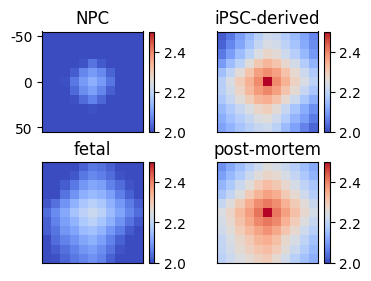

In [170]:
f=plt.figure(figsize=(4,3))
k=1
n1=['Bal_NPC','Rajarajan_NPC','Zaghi_NPC']
n2=['Ballerino','Li','Rahman_iPSC','Wu','Zaghi','PsychENCODE','Lag']
n3=['Rahman2023_Fetal','Heffel(2T)','Heffel(3T)']
n4=['Heffel(infant)','Heffel(adult)','Hu','Plet','Rahman','Tian']
labs=['NPC','iPSC-derived','fetal','post-mortem']
names=[n1,n2,n3,n4]

z=[]
for i in n2:
    xx=np.nanmean(samples_avr_nd[i],axis=2)
    z.append(xx)
iPSCder=np.nanmean(z,axis=0)

for n in [n1,n2,n3,n4]:
    f.add_subplot(2,2,k)
    z=[]
    for i in n:
        print(i)
        xx=np.nanmean(samples_avr_nd[i],axis=2)
        z.append(xx)
    zz=np.nanmean(z,axis=0)#-np.log2(iPSCder)
    plt.imshow(zz,cmap='coolwarm',vmin=2.,vmax=2.5)
    plt.colorbar()

    plt.title(labs[k-1])
    plt.yticks([])
    plt.xticks([])
    if k in [1]:
        plt.yticks([0,5,10],[-50,0,50])
    #if k in [9,10,11,12,13]:
        #plt.xticks([0,5,10],[-50,0,50])
    k+=1
plt.subplots_adjust(wspace=0.3, 
                    hspace=0.3)
#plt.tight_layout()
plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/snp_contacts_mean_nd_recalc.pdf')

Bal_NPC
Rajarajan_NPC
Zaghi_NPC
Ballerino
Li
Rahman_iPSC
Wu
Zaghi
PsychENCODE
Lag
Rahman2023_Fetal
Heffel(2T)
Heffel(3T)
Heffel(infant)
Heffel(adult)
Hu
Plet
Rahman
Tian


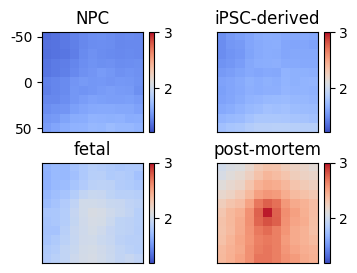

In [196]:
f=plt.figure(figsize=(4,3))
k=1
n1=['Bal_NPC','Rajarajan_NPC','Zaghi_NPC']
n2=['Ballerino','Li','Rahman_iPSC','Wu','Zaghi','PsychENCODE','Lag']
n3=['Rahman2023_Fetal','Heffel(2T)','Heffel(3T)']
n4=['Heffel(infant)','Heffel(adult)','Hu','Plet','Rahman','Tian']
labs=['NPC','iPSC-derived','fetal','post-mortem']
names=[n1,n2,n3,n4]

z=[]
for i in n2:
    xx=np.nanmean(samples_avr_ns[i],axis=2)
    z.append(xx)
iPSCder=np.nanmean(z,axis=0)

for n in [n1,n2,n3,n4]:
    f.add_subplot(2,2,k)
    z=[]
    for i in n:
        print(i)
        xx=np.nanmean(samples_avr_ns[i],axis=2)
        z.append(xx)
    zz=np.nanmean(z,axis=0)#-np.log2(iPSCder)
    plt.imshow(zz,cmap='coolwarm',vmin=1.2,vmax=3)
    plt.colorbar()

    plt.title(labs[k-1])
    plt.yticks([])
    plt.xticks([])
    if k in [1]:
        plt.yticks([0,5,10],[-50,0,50])
    #if k in [9,10,11,12,13]:
        #plt.xticks([0,5,10],[-50,0,50])
    k+=1
plt.subplots_adjust(wspace=0.3, 
                    hspace=0.3)
#plt.tight_layout()
plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/snp_contacts_mean_ns_recalc.pdf')

Bal_NPC
Rajarajan_NPC
Zaghi_NPC
Ballerino
Li
Rahman_iPSC
Wu
Zaghi
PsychENCODE
Lag
Rahman2023_Fetal
Heffel(2T)
Heffel(3T)
Heffel(infant)
Heffel(adult)
Hu
Plet
Rahman
Tian


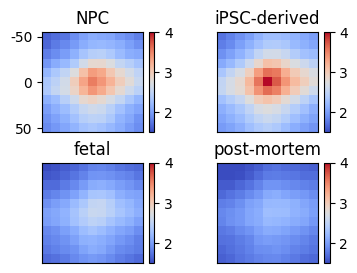

In [183]:
f=plt.figure(figsize=(4,3))
k=1
n1=['Bal_NPC','Rajarajan_NPC','Zaghi_NPC']
n2=['Ballerino','Li','Rahman_iPSC','Wu','Zaghi','PsychENCODE','Lag']
n3=['Rahman2023_Fetal','Heffel(2T)','Heffel(3T)']
n4=['Heffel(infant)','Heffel(adult)','Hu','Plet','Rahman','Tian']
labs=['NPC','iPSC-derived','fetal','post-mortem']
names=[n1,n2,n3,n4]

z=[]
for i in n2:
    xx=np.nanmean(samples_avr_cs[i],axis=2)
    z.append(xx)
iPSCder=np.nanmean(z,axis=0)

for n in [n1,n2,n3,n4]:
    f.add_subplot(2,2,k)
    z=[]
    for i in n:
        print(i)
        xx=np.nanmean(samples_avr_cs[i],axis=2)
        z.append(xx)
    zz=np.nanmean(z,axis=0)#-np.log2(iPSCder)
    plt.imshow(zz,cmap='coolwarm',vmin=1.5,vmax=4)
    plt.colorbar()

    plt.title(labs[k-1])
    plt.yticks([])
    plt.xticks([])
    if k in [1]:
        plt.yticks([0,5,10],[-50,0,50])
    #if k in [9,10,11,12,13]:
        #plt.xticks([0,5,10],[-50,0,50])
    k+=1
plt.subplots_adjust(wspace=0.3, 
                    hspace=0.3)
#plt.tight_layout()
plt.savefig('/media/anna/Samsung_T5/culture_vs_postmortem/snp_contacts_mean_cs_recalc.pdf')